# Analysis of Average monthly household income

This is notebook about analysis the dataset name "Average Household Income (รายได้เฉลี่ยของครัวเรือน)" and Answer 3 question

1. ใครได้รับค่าตอบแทนแค่ไหน? (Who earns what?)
2. ความเหลื่อมล้ำอยู่ที่ไหน? (Where is inequality?)
3. รายได้มาจากไหน และใครพึ่งพาอะไร? (What is the income structure?)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display

In [2]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = [
    "TH Sarabun New",
    "Sarabun",
    "Thonburi",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

In [3]:
REGION_MAP = {
    # Bangkok
    "กรุงเทพมหานคร": "Bangkok",
    # Central (ภาคกลาง)
    "สมุทรปราการ": "Central",
    "นนทบุรี": "Central",
    "ปทุมธานี": "Central",
    "พระนครศรีอยุธยา": "Central",
    "อ่างทอง": "Central",
    "ลพบุรี": "Central",
    "สิงห์บุรี": "Central",
    "ชัยนาท": "Central",
    "สระบุรี": "Central",
    "นครปฐม": "Central",
    "สมุทรสาคร": "Central",
    "สมุทรสงคราม": "Central",
    "ราชบุรี": "Central",
    "กาญจนบุรี": "Central",
    "สุพรรณบุรี": "Central",
    "นครสวรรค์": "Central",
    "อุทัยธานี": "Central",
    "กำแพงเพชร": "Central",
    "ตาก": "Central",
    "เพชรบุรี": "Central",
    "ประจวบคีรีขันธ์": "Central",
    # East (ภาคตะวันออก)
    "ชลบุรี": "East",
    "ระยอง": "East",
    "จันทบุรี": "East",
    "ตราด": "East",
    "ฉะเชิงเทรา": "East",
    "ปราจีนบุรี": "East",
    "นครนายก": "East",
    "สระแก้ว": "East",
    # North (ภาคเหนือ)
    "เชียงใหม่": "North",
    "ลำพูน": "North",
    "ลำปาง": "North",
    "อุตรดิตถ์": "North",
    "แพร่": "North",
    "น่าน": "North",
    "พะเยา": "North",
    "เชียงราย": "North",
    "แม่ฮ่องสอน": "North",
    "สุโขทัย": "North",
    "พิษณุโลก": "North",
    "พิจิตร": "North",
    "เพชรบูรณ์": "North",
    # Northeast (ภาคตะวันออกเฉียงเหนือ)
    "นครราชสีมา": "Northeast",
    "บุรีรัมย์": "Northeast",
    "สุรินทร์": "Northeast",
    "ศรีสะเกษ": "Northeast",
    "อุบลราชธานี": "Northeast",
    "ยโสธร": "Northeast",
    "ชัยภูมิ": "Northeast",
    "อำนาจเจริญ": "Northeast",
    "บึงกาฬ": "Northeast",
    "หนองบัวลำภู": "Northeast",
    "ขอนแก่น": "Northeast",
    "อุดรธานี": "Northeast",
    "เลย": "Northeast",
    "หนองคาย": "Northeast",
    "มหาสารคาม": "Northeast",
    "ร้อยเอ็ด": "Northeast",
    "กาฬสินธุ์": "Northeast",
    "สกลนคร": "Northeast",
    "นครพนม": "Northeast",
    "มุกดาหาร": "Northeast",
    # South (ภาคใต้)
    "นครศรีธรรมราช": "South",
    "กระบี่": "South",
    "พังงา": "South",
    "ภูเก็ต": "South",
    "สุราษฎร์ธานี": "South",
    "ระนอง": "South",
    "ชุมพร": "South",
    "สงขลา": "South",
    "สตูล": "South",
    "ตรัง": "South",
    "พัทลุง": "South",
    "ปัตตานี": "South",
    "ยะลา": "South",
    "นราธิวาส": "South",
}

## About this dataset

### Data Source
- **Source:** National Statistical Office (NSO)  
- **Published through:** Open Government Data of Thailand  
- **Website:** https://data.go.th/dataset/os_08_00007  
- **Data category:** Household income and expenditure statistics  
- **Data format:** CSV  

### Dataset Characteristics
The dataset generally includes:

- **Year of data**
- **Area** (country / region / province)
- **Type of household income**
- **Average monthly household income**

- **Unit:** Baht per month  
- **Time period:** 2023 (B.E. 2566)



### Data Dictionary
**Dataset:** Average Monthly Household Income in Thailand

| Field Name | Description | Data Type | Example |
|---|---|---|---|
| year | Year of household income data | Integer | 2566 |
| province | Province where data was collected | Text | Bangkok |
| source_income1 | Income source category level 1 | Text (Categorical) | Income from work |
| source_income2 | Income source category level 2 | Text (Categorical) | Wages and salaries |
| source_income3 | Income source category level 3 (more detailed source) | Text (Categorical) | Regular salary |
| soc_eco_class1 | Socio-economic status group of household level 1 | Text (Categorical) | Employee |
| soc_eco_class2 | Socio-economic status group of household level 2 | Text (Categorical) | Private employee |
| value | Average household income based on the specified conditions | Numeric (Float) | 28500 |
| unit | Income data unit | Text | Baht/month |
| attribute | Data attribute such as average or other statistical value | Text | Average |
| source | Data owner organization | Text | National Statistical Office |

In [4]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "avg_income.csv"

print(f"DATA_PATH     : {DATA_PATH}")

DATA_PATH     : /Users/beam/Workspace/Project/my-kaggle-notebooks/notebooks/2026-03-14-mini-hackathon-form-data-to-insight/data/avg_income.csv


In [5]:
# The file starts with a BOM character; utf-8-sig strips it automatically.
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("Shape:", df_raw.shape)
print("\nColumn dtypes:")
print(df_raw.dtypes)
print("\nFirst 5 rows:")
display(df_raw.head())

Shape: (7700, 11)

Column dtypes:
year                int64
province              str
source_income1        str
source_income2        str
source_income3        str
soc_eco_class1        str
soc_eco_class2        str
value             float64
unit                  str
attribute             str
source                str
dtype: object

First 5 rows:


,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,unit,attribute,source
0,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"29,549.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
1,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ประจำ,รายได้ประจำ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"29,549.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
2,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้ที่เป็นตัวเงิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"23,925.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
3,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,ค่าจ้างและเงินเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ
4,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำธุรกิจ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ


## Data Preparation

In [6]:
df = df_raw.copy()

### Null values 

In [7]:
null_counts = df.isna().sum().sort_values(ascending=False)
null_pct = (df.isna().mean() * 100).round(2)
null_summary = pd.DataFrame(
    {
        "null_count": null_counts,
        "null_pct": null_pct.reindex(null_counts.index),
    }
)
null_summary = null_summary[null_summary["null_count"] > 0]

display(null_summary)

,null_count,null_pct
attribute,6865,89.16


In [8]:
candidate_names = {"attribute", "attritbute", "attritube"}
attribute_candidates = [
    c for c in df.columns if str(c).strip().lower() in candidate_names
]
if not attribute_candidates:
    attribute_candidates = [c for c in df.columns if "attrib" in str(c).lower()]

if not attribute_candidates:
    raise KeyError(
        "Could not find an attribute-like column. "
        f"Columns available: {list(df.columns)}"
    )

attribute_col = attribute_candidates[0]
print(f"Using attribute column: {attribute_col}")

Using attribute column: attribute


In [9]:
attribute_series = df[attribute_col]
attribute_clean = attribute_series.replace(r"^\s*$", np.nan, regex=True)

attribute_dist = (
    attribute_clean.fillna("<<MISSING>>")
    .value_counts(dropna=False)
    .rename_axis(attribute_col)
    .reset_index(name="rows")
)
attribute_dist["pct"] = (attribute_dist["rows"] / len(df) * 100).round(2)

display(attribute_dist)

attribute_missing_count = int(attribute_clean.isna().sum())
attribute_missing_pct = round(attribute_missing_count / len(df) * 100, 2)
print(
    f"Missing or blank in {attribute_col}: "
    f"{attribute_missing_count:,} rows ({attribute_missing_pct}%)"
)

,attribute,rows,pct
0,<<MISSING>>,6865,89.16
1,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,812,10.55
2,ศูนย์ยกกำลังอาร์ดี หมายถึง ข้อมูลที่ปัดเศษแล้ว...,22,0.29
3,ลบศูนย์ยกกำลังอาร์ดี หมายถึง ข้อมูลที่ปัดเศษแล...,1,0.01


Missing or blank in attribute: 6,865 rows (89.16%)


#### Null Handling

- attribute is null in 6865 out of 7700 rows (89.16%).
- this null pattern looks structural, meaning no special source note, not missing income measurement.
- other key columns remain populated even when attribute is null, so null is isolated to this metadata field.

So with this information we can keep this null values don't need to be filled or do anything

### Duplicate values

In [10]:
duplicate_rows = int(df.duplicated().sum())
display(duplicate_rows)

0

### Zero values

In [11]:
if "value" not in df.columns:
    raise KeyError("Column 'value' not found in df.")

value_numeric = pd.to_numeric(df["value"], errors="coerce")
numeric_count = int(value_numeric.notna().sum())
print(f"Numeric rows detected in value: {numeric_count:,} / {len(df):,}")

if numeric_count == 0:
    print("No numeric values found in value column. Skip zero-value check.")
    df["is_zero"] = False
    zero_rows = 0
else:
    df["is_zero"] = value_numeric.eq(0)
    zero_rows = int(df["is_zero"].sum())
    print(f"Rows where value == 0: {zero_rows:,}")

Numeric rows detected in value: 7,700 / 7,700
Rows where value == 0: 835


In [12]:
if "zero_rows" not in globals():
    zero_rows = int(df["is_zero"].sum()) if "is_zero" in df.columns else 0

zero_pct = round(zero_rows / len(df) * 100, 2) if len(df) else 0.0

if zero_rows == 0:
    print("No rows have value == 0.")
    finding = "No rows have value == 0"
    action_taken = "No action needed"
else:
    print(f"{zero_rows:,} rows have value == 0 ({zero_pct}%).")
    finding = f"{zero_rows:,} rows have value == 0"
    action_taken = "Added is_zero flag for downstream filters"

zero_check_summary = pd.DataFrame(
    [
        {
            "check": "Zero values",
            "finding": finding,
            "action_taken": action_taken,
            "rows_affected": zero_rows,
        }
    ]
)
display(zero_check_summary)

835 rows have value == 0 (10.84%).


,check,finding,action_taken,rows_affected
0,Zero values,835 rows have value == 0,Added is_zero flag for downstream filters,835


In [13]:
df["is_zero"] = df["value"] == 0.0

#### Zero Handling

- value is zero in 835 out of 7700 rows (10.84%).
- this pattern appears meaningful for analysis and is not a data loading issue.
- we keep zero rows in the raw dataset and create an is_zero flag for controlled filtering in downstream aggregates.

So with this information we keep these zero values and only exclude them when a specific analysis requires non-zero income rows.

### Negative values

In [14]:
value_numeric = pd.to_numeric(df["value"], errors="coerce")
df["is_negative"] = value_numeric.lt(0)

negative_rows = int(df["is_negative"].sum())
negative_pct = round(negative_rows / len(df) * 100, 2) if len(df) else 0.0
negative_min_value = float(value_numeric.min())

print(f"Rows with value < 0: {negative_rows:,} / {len(df):,} ({negative_pct}%)")
print(f"Minimum value in value column: {negative_min_value:,.2f}")

Rows with value < 0: 36 / 7,700 (0.47%)
Minimum value in value column: -2,250.00


In [15]:
negative_rows_df = df.loc[df["is_negative"]].copy()

negative_preview_cols = [
    "year",
    "province",
    "source_income1",
    "source_income2",
    "source_income3",
    "soc_eco_class1",
    "soc_eco_class2",
    "value",
    "attribute",
]
negative_preview_cols = [
    c for c in negative_preview_cols if c in negative_rows_df.columns
]

display(negative_rows_df[negative_preview_cols].head(10))

print("\nTop attribute notes for negative rows")
negative_attribute_notes = (
    negative_rows_df.get("attribute", pd.Series(dtype="object"))
    .fillna("<<MISSING>>")
    .value_counts()
    .rename_axis("attribute")
    .reset_index(name="rows")
)
display(negative_attribute_notes.head(10))

,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,attribute
85,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ลูกจ้าง,ผู้ปฏิบัติงานในกระบวนการผลิตก่อสร้างและเหมืองแร่,-27.00,NaN
95,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,-13.00,NaN
479,2566,พระนครศรีอยุธยา,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ลูกจ้าง,เสมียนพนักงานขายและให้บริการ,-3.00,NaN
745,2566,สิงห์บุรี,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ลูกจ้าง,ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ,-278.00,NaN
922,2566,สระบุรี,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้ที่เป็นตัวเงิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร,"-1,048.00",NaN
928,2566,สระบุรี,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร,"-1,048.00",NaN
1098,2566,ชลบุรี,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,-58.00,NaN
1255,2566,จันทบุรี,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ลูกจ้าง,คนงานเกษตรป่าไม้และประมง,-15.00,NaN
1565,2566,ปราจีนบุรี,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ลูกจ้าง,คนงานด้านการขนส่งและงานพื้นฐาน,-2.00,NaN
1765,2566,สระแก้ว,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ลูกจ้าง,คนงานด้านการขนส่งและงานพื้นฐาน,-25.00,NaN



Top attribute notes for negative rows


,attribute,rows
0,<<MISSING>>,36


#### Negative Handling

From the checks above:

- negative values exist, but only in a small subset of rows.
- we reviewed example rows and attribute notes before deciding on action.
- this looks like a case to track explicitly, not to drop blindly.

Decision: keep negative rows in the raw dataset, use is_negative as a control flag, and exclude only when a specific analysis requires non-negative income values.

### Year adjust

-  Buddhist Era → Gregorian year

In [16]:
df["year_ce"] = df["year"] - 543

### Categorical Cardinality

Identify the cardinality of each categorical column to understand the dimension of the dataset.

In [17]:
for col in [
    "province",
    "source_income1",
    "source_income2",
    "source_income3",
    "soc_eco_class1",
    "soc_eco_class2",
]:
    print(f"{col}: {df[col].nunique()} unique values")

province: 77 unique values
source_income1: 3 unique values
source_income2: 5 unique values
source_income3: 10 unique values
soc_eco_class1: 4 unique values
soc_eco_class2: 10 unique values


### Value Distribution

Statistical summary of the income value column to identify the range, central tendency, and spread of household income.

In [18]:
df["value"].describe()

count     7,700.00
mean      9,697.00
std      13,793.78
min      -2,250.00
25%         256.00
50%       2,588.50
75%      16,577.75
max     181,322.00
Name: value, dtype: float64

### Value Distribution

Statistical summary of the income value column to identify the range, central tendency, and spread of household income.

In [19]:
df.groupby("soc_eco_class1")["value"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
soc_eco_class1,,,,,
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,2310,"9,062.07","2,411.00","-2,250.00","181,322.00"
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร,770,"12,843.45","3,257.50",0.00,"57,308.00"
ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,770,"7,193.26","3,324.00","-1,386.00","42,764.00"
ลูกจ้าง,3850,"9,949.42","2,588.50","-1,495.00","77,569.00"


### Data Sparsity Analysis

Check whether all combinations of provinces, income sources, and socio-economic classes exist in the dataset, or if there are structural gaps. This reveals whether certain groups/regions have income data for all source types and helps identify what analysis is actually available across the full dimension space.

In [20]:
combinations = df.groupby(["province", "source_income1", "soc_eco_class1"]).size()
print(
    f"Observed combinations: {len(combinations)} / {df['province'].nunique() * df['source_income1'].nunique() * df['soc_eco_class1'].nunique()} possible"
)

Observed combinations: 924 / 924 possible


In [21]:
df["region"] = df["province"].map(REGION_MAP)

unmapped = df[df["region"].isna()]["province"].unique()
if len(unmapped) == 0:
    print("All 77 provinces mapped successfully.")
else:
    print("WARNING — unmapped provinces:", unmapped)

print("\nProvince count per region:")
print(df.drop_duplicates("province")["region"].value_counts().to_string())

REGION_COLORS = {
    "Bangkok": "#e63946",
    "Central": "#457b9d",
    "East": "#2a9d8f",
    "North": "#e9c46a",
    "Northeast": "#f4a261",
    "South": "#a8dadc",
}
print("\nRegion color palette set.")

All 77 provinces mapped successfully.

Province count per region:
region
Central      21
Northeast    20
South        14
North        13
East          8
Bangkok       1

Region color palette set.


# EDA Exploratory Data Analysis

Before answering the three questions, we explore the overall income distribution and KPIs.  
This surfaces deeper questions that guide the analysis.

## Income Hierachy (source_income1 → 2 → 3)

In [22]:
import plotly.graph_objects as go

required_cols = ["source_income1", "source_income2", "source_income3", "value"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns for hierarchy Sankey: {missing_cols}")

hierarchy_df = df[required_cols].copy()
hierarchy_df["value_num"] = pd.to_numeric(hierarchy_df["value"], errors="coerce")

for col in ["source_income1", "source_income2", "source_income3"]:
    hierarchy_df[col] = (
        hierarchy_df[col]
        .astype("string")
        .str.strip()
        .fillna("<<MISSING>>")
        .replace("", "<<MISSING>>")
    )

total_rows = len(hierarchy_df)
invalid_value_rows = int(hierarchy_df["value_num"].isna().sum())

# Sankey links must be non-negative; keep positive monthly income only.
sankey_df = hierarchy_df[hierarchy_df["value_num"].gt(0)].copy()
removed_rows = total_rows - len(sankey_df)

if sankey_df.empty:
    raise ValueError("No positive numeric rows available to build the Sankey diagram.")

level12 = (
    sankey_df.groupby(["source_income1", "source_income2"], as_index=False)["value_num"]
    .sum()
    .sort_values("value_num", ascending=False)
)
level23 = (
    sankey_df.groupby(["source_income2", "source_income3"], as_index=False)["value_num"]
    .sum()
    .sort_values("value_num", ascending=False)
)

l1_labels = sorted(level12["source_income1"].unique().tolist())
l2_labels = sorted(
    pd.Index(level12["source_income2"])
    .union(pd.Index(level23["source_income2"]))
    .tolist()
)
l3_labels = sorted(level23["source_income3"].unique().tolist())

node_keys = [f"L1::{label}" for label in l1_labels]
node_keys += [f"L2::{label}" for label in l2_labels]
node_keys += [f"L3::{label}" for label in l3_labels]

node_labels = l1_labels + l2_labels + l3_labels
node_colors = (
    ["#355070"] * len(l1_labels)
    + ["#6D597A"] * len(l2_labels)
    + ["#B56576"] * len(l3_labels)
)
key_to_idx = {key: idx for idx, key in enumerate(node_keys)}

source_indices = []
target_indices = []
values = []
link_colors = []

for row in level12.itertuples(index=False):
    source_indices.append(key_to_idx[f"L1::{row.source_income1}"])
    target_indices.append(key_to_idx[f"L2::{row.source_income2}"])
    values.append(float(row.value_num))
    link_colors.append("rgba(53, 80, 112, 0.35)")

for row in level23.itertuples(index=False):
    source_indices.append(key_to_idx[f"L2::{row.source_income2}"])
    target_indices.append(key_to_idx[f"L3::{row.source_income3}"])
    values.append(float(row.value_num))
    link_colors.append("rgba(109, 89, 122, 0.35)")

total_income = float(sankey_df["value_num"].sum())

print(f"Rows in raw hierarchy table: {total_rows:,}")
print(f"Rows removed due to non-numeric value: {invalid_value_rows:,}")
print(f"Rows removed due to non-positive value: {removed_rows - invalid_value_rows:,}")
print(f"Rows used in Sankey: {len(sankey_df):,}")
print(f"Total positive monthly income represented: {total_income:,.2f} baht")

display(
    sankey_df.groupby("source_income1", as_index=False)["value_num"]
    .sum()
    .sort_values("value_num", ascending=False)
    .rename(columns={"value_num": "total_income_baht"})
)

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=16,
                thickness=16,
                line=dict(color="rgba(0, 0, 0, 0.25)", width=0.5),
                label=node_labels,
                color=node_colors,
            ),
            link=dict(
                source=source_indices,
                target=target_indices,
                value=values,
                color=link_colors,
                hovertemplate=(
                    "From: %{source.label}<br>"
                    "To: %{target.label}<br>"
                    "Monthly income: %{value:,.0f} baht<extra></extra>"
                ),
            ),
        )
    ]
)

fig.update_layout(
    title="Income Hierarchy Sankey: source_income1 -> source_income2 -> source_income3",
    height=760,
    font=dict(size=12),
    margin=dict(l=20, r=20, t=70, b=20),
)

try:
    fig.show()
except ValueError as exc:
    if "nbformat" in str(exc).lower():
        from IPython.display import HTML

        display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))
    else:
        raise

Rows in raw hierarchy table: 7,700
Rows removed due to non-numeric value: 0
Rows removed due to non-positive value: 871
Rows used in Sankey: 6,829
Total positive monthly income represented: 74,680,778.00 baht


,source_income1,total_income_baht
1,รายได้ประจำ,"54,990,836.00"
0,รายได้ทั้งสิ้นต่อเดือน,"19,502,606.00"
2,รายได้ไม่ประจำ (ที่เป็นตัวเงิน),"187,336.00"


### Take aways

- The income hierarchy is highly concentrated in รายได้ประจำ, contributing about 73.6% of total positive monthly income flow.
- รายได้ทั้งสิ้นต่อเดือน is the second largest branch at about 26.1%, while รายได้ไม่ประจำ (ที่เป็นตัวเงิน) is very small at about 0.25%.
- Most flow thickness in the Sankey comes from a small number of dominant paths from level 1 to level 2, showing a clear structural concentration.
- 6,829 rows are used in the Sankey after filtering, and 871 non-positive rows are excluded to keep flow values valid and interpretable.
- This hierarchy suggests that policy or intervention focused on regular-income channels will influence the largest share of household income structure.

## National Income

In [30]:
TOTAL_INCOME_LABEL = "รายได้ทั้งสิ้นต่อเดือน"

df_total = df[(df["source_income3"] == TOTAL_INCOME_LABEL) & (~df["is_zero"])].copy()

kpi = {
    "national_avg_income": df_total["value"].mean(),
    "national_median_income": df_total["value"].median(),
    "min_income": df_total["value"].min(),
    "max_income": df_total["value"].max(),
    "income_range": df_total["value"].max() - df_total["value"].min(),
    "n_provinces": df_total["province"].nunique(),
    "n_occupation_groups": df_total["soc_eco_class2"].nunique(),
}
kpi_df = pd.DataFrame([kpi])

display(kpi_df)

,national_avg_income,national_median_income,min_income,max_income,income_range,n_provinces,n_occupation_groups
0,"26,177.19","22,824.00",-600.00,"181,322.00","181,922.00",77,10


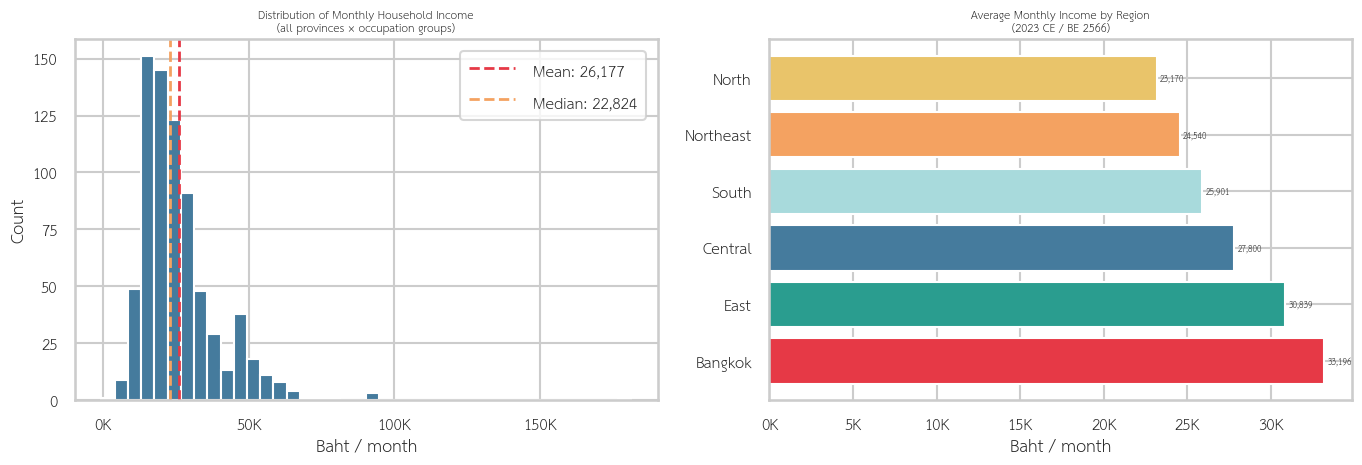

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_total["value"], bins=40, edgecolor="white", color="#457b9d")
axes[0].axvline(
    df_total["value"].mean(),
    color="#e63946",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df_total['value'].mean():,.0f}",
)
axes[0].axvline(
    df_total["value"].median(),
    color="#f4a261",
    linestyle="--",
    linewidth=2,
    label=f"Median: {df_total['value'].median():,.0f}",
)
axes[0].set_title(
    "Distribution of Monthly Household Income\n(all provinces × occupation groups)",
    fontsize=12,
)
axes[0].set_xlabel("Baht / month")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K")
)

region_avg = df_total.groupby("region")["value"].mean().sort_values(ascending=False)
colors_r = [REGION_COLORS[r] for r in region_avg.index]
axes[1].barh(region_avg.index, region_avg.values, color=colors_r, edgecolor="white")
axes[1].set_title("Average Monthly Income by Region\n(2023 CE / BE 2566)", fontsize=12)
axes[1].set_xlabel("Baht / month")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K")
)
for i, (region, val) in enumerate(region_avg.items()):
    axes[1].text(val + 200, i, f"{val:,.0f}", va="center", fontsize=9)

plt.tight_layout()

### Take aways

- The distribution is right-skewed: the national mean is 26,177 baht, above the median of 22,824 baht.
- The minimum value is -600 baht, so the dataset includes a few unusual or adjusted observations that should be interpreted carefully.

This raises two deeper questions for the main analysis: which occupation groups drive the top end of the distribution, and which provinces combine high averages with wide internal gaps?

## Question 1, Who earns what?


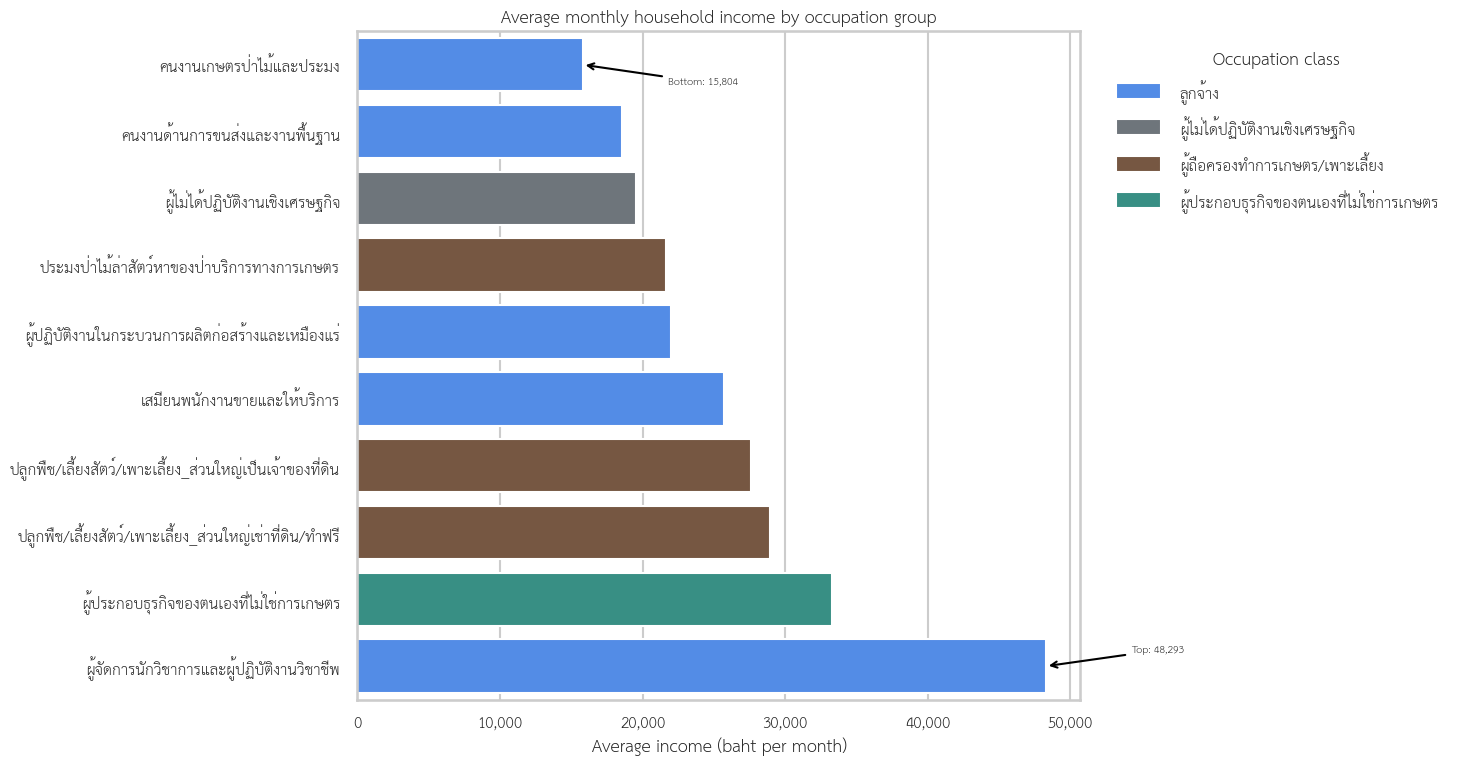

In [31]:
q1_df = (
    df_total.groupby(["soc_eco_class1", "soc_eco_class2"], as_index=False)["value"]
    .mean()
    .sort_values("value", ascending=True)
)

class_palette = {
    "ผู้ถือครองทำการเกษตร/เพาะเลี้ยง": "#7f5539",
    "ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร": "#2a9d8f",
    "ลูกจ้าง": "#3a86ff",
    "ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ": "#6c757d",
}

fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(
    data=q1_df,
    x="value",
    y="soc_eco_class2",
    hue="soc_eco_class1",
    dodge=False,
    palette=class_palette,
    ax=ax,
)
ax.set_title("Average monthly household income by occupation group")
ax.set_xlabel("Average income (baht per month)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(
    title="Occupation class", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
)

highest = q1_df.iloc[-1]
lowest = q1_df.iloc[0]
income_gap = highest["value"] - lowest["value"]
income_ratio = highest["value"] / lowest["value"]

ax.annotate(
    f"Top: {highest['value']:,.0f}",
    xy=(highest["value"], len(q1_df) - 1),
    xytext=(highest["value"] + 6000, len(q1_df) - 1.2),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=11,
)
ax.annotate(
    f"Bottom: {lowest['value']:,.0f}",
    xy=(lowest["value"], 0),
    xytext=(lowest["value"] + 6000, 0.3),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=11,
)
plt.tight_layout()
plt.show()


### Q1 takeaway

- The highest average income belongs to ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ at 48,293 baht/month.
- The lowest average income belongs to คนงานเกษตรป่าไม้และประมง at 15,804 baht/month.
- The gap is 32,489 baht/month, or about 3.1x from top to bottom.

In [32]:
REGULAR_LABEL = "รายได้ประจำ"
IRREGULAR_LABEL = "รายได้ไม่ประจำ (ที่เป็นตัวเงิน)"

## Q2 Where is inequality?

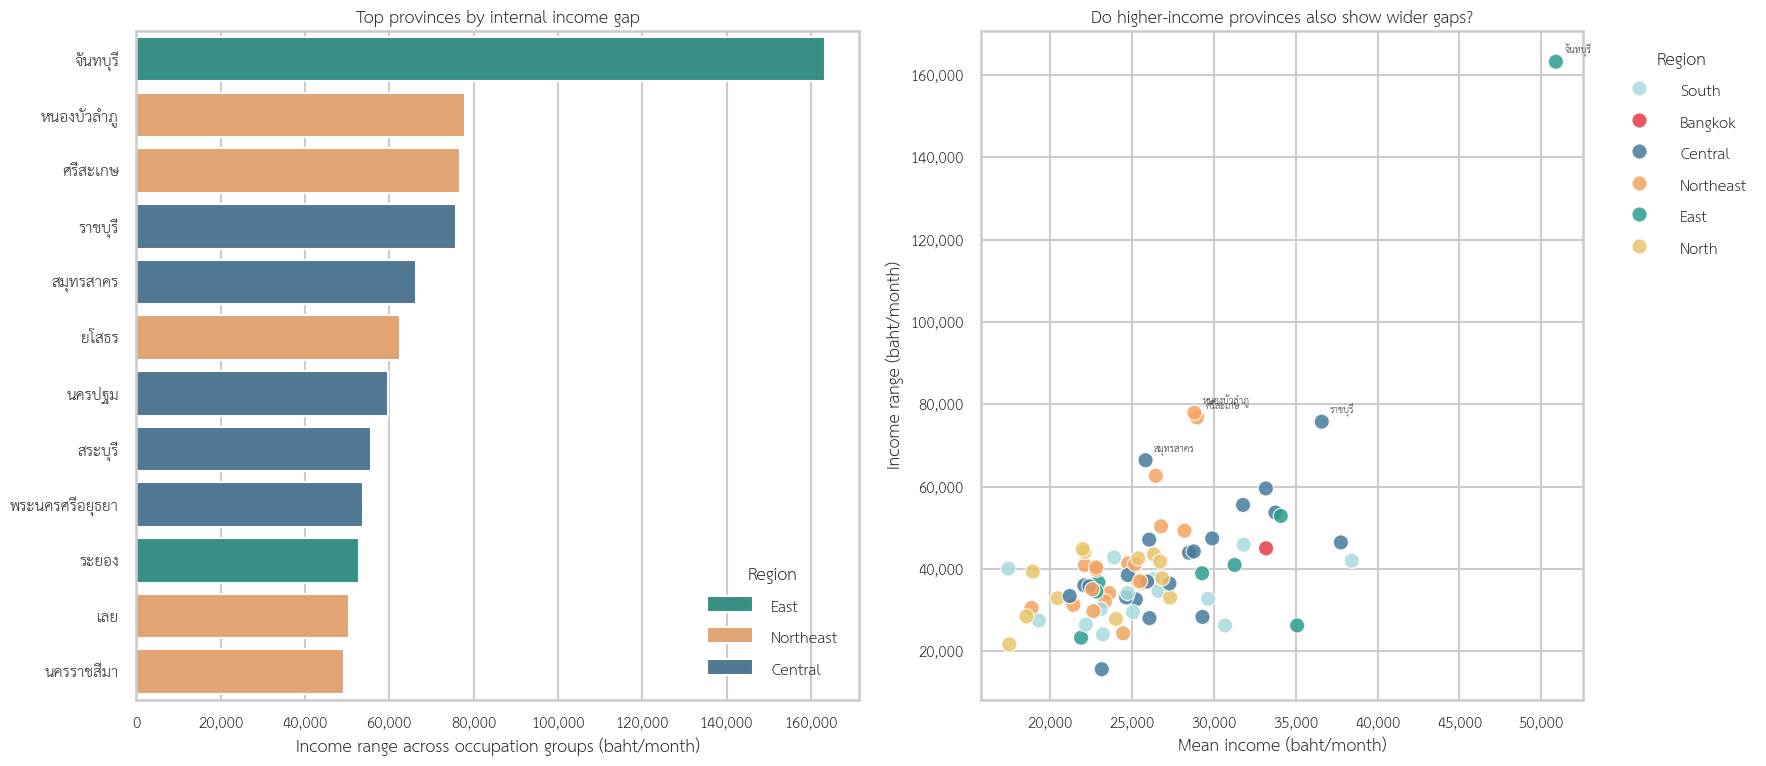

province         จันทบุรี
mean_income     50,893.00
max_income     181,322.00
min_income      18,092.00
income_range   163,230.00
cv                   0.91
region               East
Name: 6, dtype: object

In [36]:
# Cell: Q2 analysis
df_latest = df_total[df_total["year_ce"] == df_total["year_ce"].max()].copy()

province_stats = (
    df_latest.groupby("province")["value"]
    .agg(
        mean_income="mean",
        max_income="max",
        min_income="min",
        income_range=lambda x: x.max() - x.min(),
        cv=lambda x: x.std(ddof=0) / x.mean(),
    )
    .reset_index()
)
province_stats["region"] = province_stats["province"].map(REGION_MAP)

top_provinces = (
    province_stats.sort_values("income_range", ascending=False).head(12).copy()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.2, 1]})

sns.barplot(
    data=top_provinces,
    x="income_range",
    y="province",
    hue="region",
    dodge=False,
    palette=REGION_COLORS,
    ax=axes[0],
)
axes[0].set_title("Top provinces by internal income gap")
axes[0].set_xlabel("Income range across occupation groups (baht/month)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
axes[0].legend(title="Region", frameon=False, loc="lower right")

sns.scatterplot(
    data=province_stats,
    x="mean_income",
    y="income_range",
    hue="region",
    palette=REGION_COLORS,
    s=120,
    alpha=0.85,
    ax=axes[1],
)
axes[1].set_title("Do higher-income provinces also show wider gaps?")
axes[1].set_xlabel("Mean income (baht/month)")
axes[1].set_ylabel("Income range (baht/month)")
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

label_df = province_stats.sort_values("income_range", ascending=False).head(5)
for _, row in label_df.iterrows():
    axes[1].annotate(
        row["province"],
        (row["mean_income"], row["income_range"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
    )

axes[1].legend(
    title="Region", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
)
plt.tight_layout()
plt.show()

most_unequal = province_stats.sort_values("income_range", ascending=False).iloc[0]
display(most_unequal)


### Q2 takeaway

- จันทบุรี shows the widest internal income gap at 163,230 baht/month.
- Its average income is 50,893 baht/month, which shows that high earning power and high inequality can coexist.
- Several of the highest-gap provinces come from Central, East, and Northeast areas, suggesting that place-based policy should focus not only on raising income, but also on narrowing local disparities.

## Q3 What is the income structure?

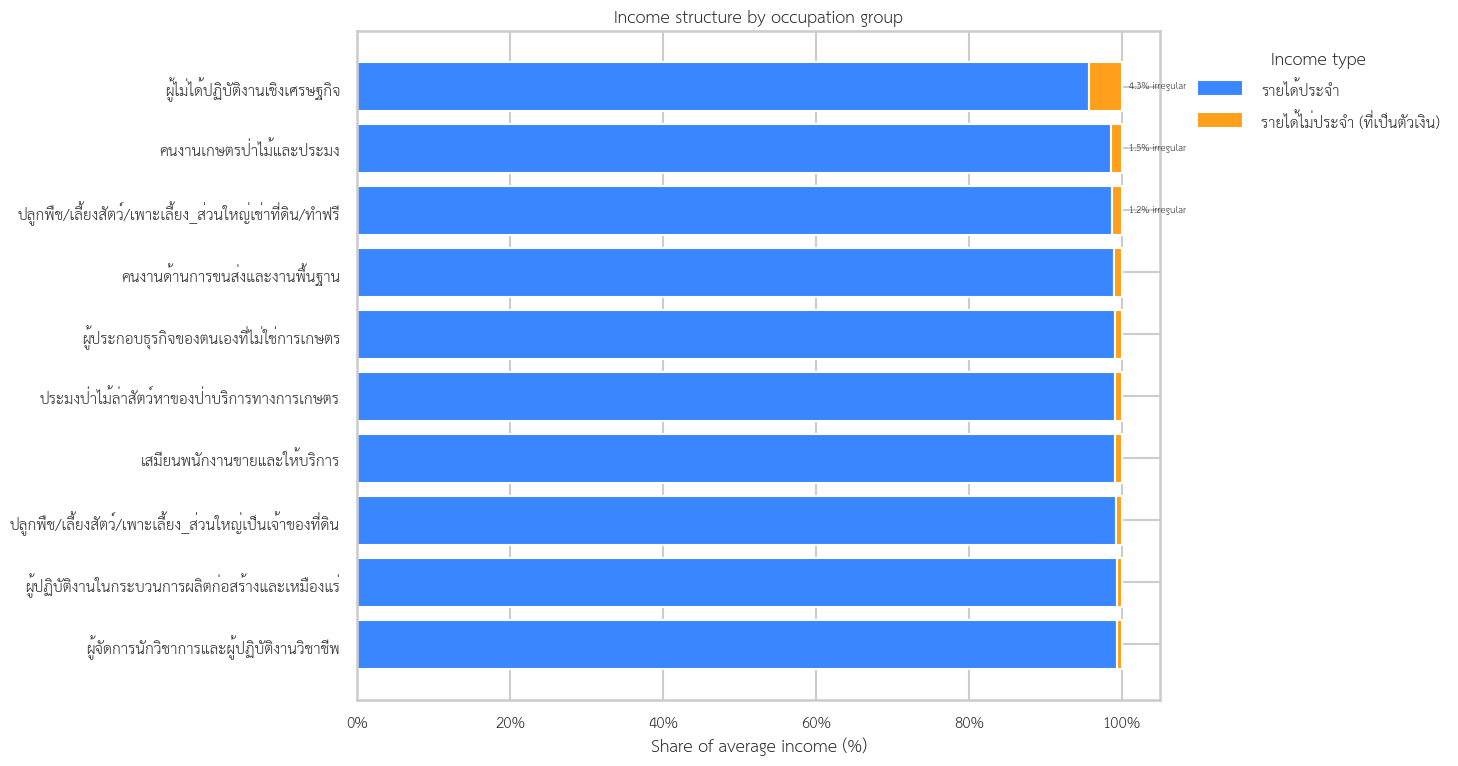

In [38]:
# Cell: Q3 analysis
df_structure = df[
    (df["source_income3"].isin([REGULAR_LABEL, IRREGULAR_LABEL])) & (~df["is_zero"])
].copy()

pivot = (
    df_structure.groupby(["soc_eco_class2", "source_income3"])["value"]
    .mean()
    .unstack(fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.sort_values(IRREGULAR_LABEL, ascending=True)

fig, ax = plt.subplots(figsize=(15, 8))
left = np.zeros(len(pivot_pct))
structure_colors = {
    REGULAR_LABEL: "#3a86ff",
    IRREGULAR_LABEL: "#ff9f1c",
}

for column in [REGULAR_LABEL, IRREGULAR_LABEL]:
    values = pivot_pct[column].to_numpy()
    ax.barh(
        pivot_pct.index, values, left=left, label=column, color=structure_colors[column]
    )
    left += values

ax.set_title("Income structure by occupation group")
ax.set_xlabel("Share of average income (%)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(
    title="Income type", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
)

top_irregular = pivot_pct.sort_values(IRREGULAR_LABEL, ascending=False).head(3)
for idx, (_, row) in enumerate(top_irregular.iterrows()):
    ax.text(
        101,
        len(pivot_pct) - idx - 1,
        f"{row[IRREGULAR_LABEL]:.1f}% irregular",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

highest_irregular_group = top_irregular.index[0]
highest_irregular_share = top_irregular.iloc[0][IRREGULAR_LABEL]


### Q3 takeaway

- The occupation group with the highest irregular-income share is ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ at 4.3%.
- Even the highest group is still dominated by regular income, so this dataset suggests that the bigger structural issue is income level and inequality, not extreme irregular dependence.
- Still, relative differences matter: the groups with the largest irregular shares are the ones that may be more exposed to unstable cash flow when shocks occur.

## Key Insight

**Q1 - Who earns what?**  
Managers, professionals, and technical workers earn the highest monthly incomes, while agricultural labor groups earn the least. This gap reflects differences in skills, job security, and bargaining power in the labor market. Higher-skill occupations benefit from stronger demand and formal employment structures, while agricultural and manual work often involves lower wages and seasonal income. This means income policy should not treat workers as a single group. Lower-earning occupations need targeted support such as skills training, wage protection, and better access to stable employment.

**Q2 - Where is inequality?**  
Some provinces, such as Chanthaburi, show large income gaps within the same area. High-income and low-income workers live side by side. This often happens in places with mixed economic activity where commercial or urban sectors create well-paid jobs while service, agricultural, or manual roles remain low paid. Because of this, looking only at provincial average income can hide serious inequality. Regional policy should focus on inclusion and local support in provinces where these internal gaps are large.

**Q3 - What is the income structure?**  
Regular income makes up most earnings across all occupation groups, though some groups still rely slightly more on irregular income than others. While irregular income is not the dominant source overall, differences in income stability still matter. Groups with lower earnings and less predictable income are more exposed to financial shocks. So the main policy concern is not extreme dependence on irregular income alone, but how income instability can make already low-income groups more vulnerable.